# Importing packages

In [1]:
import os
from pathlib import Path
from functools import partial

import numpy as np

import rasterio
from rasterio.plot import reshape_as_image, reshape_as_raster
from rasterio.warp import reproject, calculate_default_transform, Resampling

import torch
import omnicloudmask
from omnicloudmask import predict_from_array

import matplotlib
from matplotlib import pyplot as plt

# Loading imagery

{'driver': 'GTiff', 'dtype': 'int16', 'nodata': -999.0, 'width': 2446, 'height': 2408, 'count': 4, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 51S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32751"]]'), 'transform': Affine(10.0, 0.0, 191060.0,
       0.0, -10.0, 7432740.0), 'blockxsize': 1024, 'blockysize': 1024, 'tiled': True, 'compress': 'deflate', 'interleave': 'pixel'}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.20917523..4.8002095].


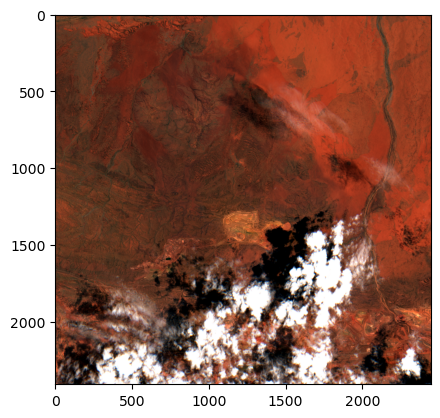

In [ ]:
img_path = Path(r"T:\Sumesh\RD\004_Cloud_Masking\case_study\1_Acacia_Corusca\s2_20260102.tif")

with rasterio.open(img_path) as ds:
    print(ds.profile)
    nodata = ds.nodata
    img_arr = ds.read()

temp_img_arr = img_arr.copy().astype(np.float32)
temp_img_arr[temp_img_arr == nodata] = np.nan
temp_img_arr = temp_img_arr/10000
for i in range(temp_img_arr.shape[0]):
    temp_img_arr[i] = (temp_img_arr[i] - np.nanquantile(temp_img_arr[i], 0.02)) / (np.nanquantile(temp_img_arr[i], 0.98) - np.nanquantile(temp_img_arr[i], 0.02))

plt.imshow(reshape_as_image(temp_img_arr)[:,:,[2, 1, 0]]*1.5)
plt.show()

# Cloud and cloud shadows detection

In [4]:
# running omnicloudmask
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device: {}'.format(device))

# choose large patch size for improving thin cloud and cloud shadow detection, and set some overlap to mitigate edge artifacts
patch_size = 1000
patch_overlap = 300 

# input array should be in the order of R, G, NIR
mask = predict_from_array(input_array = img_arr[[2, 1, 3]], patch_size = patch_size, patch_overlap = patch_overlap, batch_size = 1,
                          inference_device = device, mosaic_device = device, inference_dtype = torch.float32,
                          no_data_value = nodata, apply_no_data_mask = True) 

Device: cuda


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13945015..3.2001398].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13945015..3.2001398].


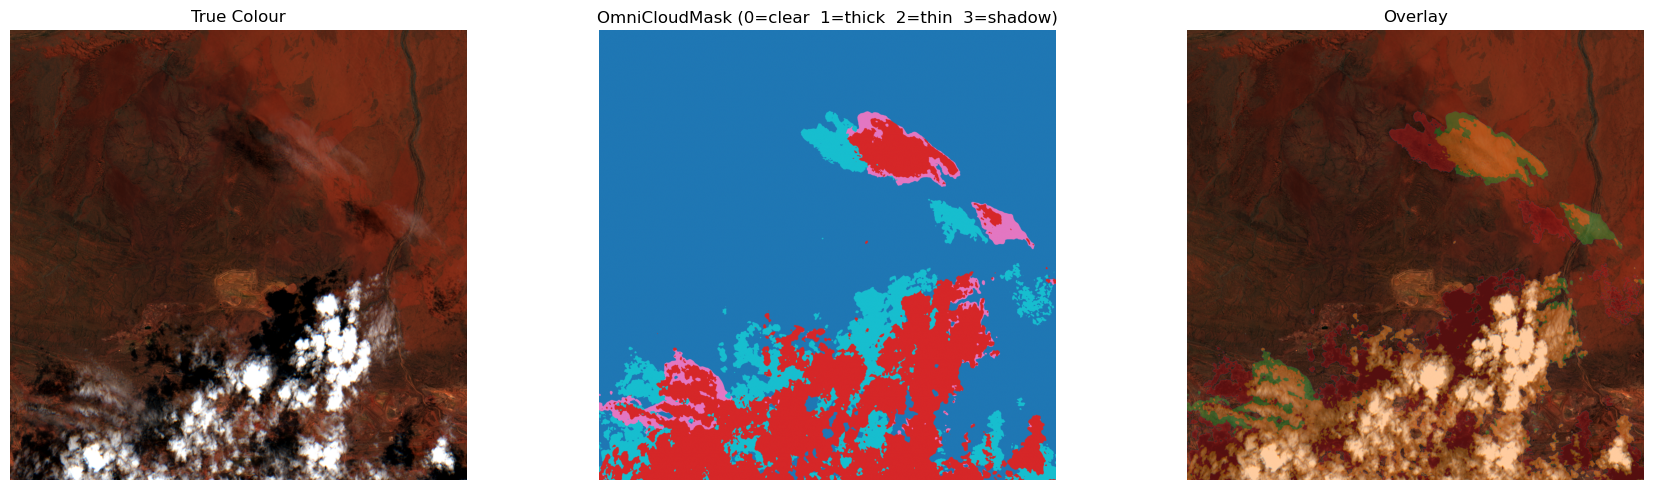

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rgb_display = reshape_as_image(temp_img_arr)[:,:,[2, 1, 0]]

axes[0].imshow(rgb_display)
axes[0].set_title("True Colour")
axes[0].axis("off")

axes[1].imshow(mask.squeeze(), cmap="tab10", vmin=0, vmax=3)
axes[1].set_title("OmniCloudMask (0=clear  1=thick  2=thin  3=shadow)")
axes[1].axis("off")

tab10 = plt.get_cmap("tab10")
mask_sq = mask.squeeze()
rgba = np.zeros((*mask_sq.shape, 4), dtype=float)
for cls in range(4):
    colour = tab10(cls / 9)
    where = mask_sq == cls
    rgba[where, :3] = colour[:3]
    rgba[where, 3] = 0.0 if cls == 0 else 0.4

axes[2].imshow(rgb_display)
axes[2].imshow(rgba)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [6]:
# printing the proportion of cloud and cloud shadows
print("Clear pixels (0): {:.2f} %".format(np.sum(mask == 0) / mask.size * 100))
print("Thick cloud pixels (1): {:.2f} %".format(np.sum(mask == 1) / mask.size * 100))
print("Thin cloud pixels (2): {:.2f} %".format(np.sum(mask == 2) / mask.size * 100))
print("Cloud shadow pixels (3): {:.2f} %".format(np.sum(mask == 3) / mask.size * 100))

Clear pixels (0): 68.87 %
Thick cloud pixels (1): 19.86 %
Thin cloud pixels (2): 2.34 %
Cloud shadow pixels (3): 8.94 %


## Masking cloud and cloud shadows

In [ ]:
# applying mask and saving the results
with rasterio.open(img_path) as ds:
    profile = ds.profile
    print(profile)
    res = ds.res[0]
    nodata = profile['nodata']

    profile.update({'tiled': True, 
                    'compress': 'lzw',
                    'blockxsize': 1024, 
                    'blockysize': 1024})

    # apply the mask to all bands
    img_arr = ds.read()
    mask_img_arr = ds.read_masks(1)

    # set masked pixels to nodata value
    masked_arr = np.where((mask_sq == 0) & (ds.read(1) != nodata), img_arr, nodata)

    # saving masked raster
    out_img_path = img_path.parent.joinpath(img_path.stem + '_cloud_masked.tif')
    print('Output raster: {}'.format(out_img_path))
    # if not os.path.exists(out_img_path):
    with rasterio.open(out_img_path, 'w', **profile) as dst:
        dst.write(masked_arr)

    # saving mask raster
    mask_sq = np.where((mask_img_arr > 0), mask_sq, 255)
    mask_profile = profile.copy()
    mask_profile.update({'count': 1, 'dtype': mask_sq.dtype, 'nodata': 255}) # changing nodata value to 255 for the mask, as 0 is a valid class in the mask
    out_mask_path = img_path.parent.joinpath(img_path.stem + '_cloud_mask.tif')
    # if not os.path.exists(out_mask_path):
    with rasterio.open(out_mask_path, 'w', **mask_profile) as dst:
        dst.write(mask_sq, 1)

{'driver': 'GTiff', 'dtype': 'int16', 'nodata': -999.0, 'width': 2446, 'height': 2408, 'count': 4, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 51S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32751"]]'), 'transform': Affine(10.0, 0.0, 191060.0,
       0.0, -10.0, 7432740.0), 'blockxsize': 1024, 'blockysize': 1024, 'tiled': True, 'compress': 'deflate', 'interleave': 'pixel'}
Output raster: T:\Sumesh\RD\004_Cloud_Masking\case_study\1_Acacia_Corusca\s2_20260102_cloud_masked